# 🧹 02 - Data Cleaning and Preprocessing
## Product Price Prediction Project
**Week 1-2 | Unit I**

### Tasks:
1. ✅ Handle missing values (price, rating, reviews)
2. ✅ Remove duplicates
3. ✅ Clean currency symbols (₹, commas)
4. ✅ Outlier detection (IQR on price)
5. ✅ Encode categorical columns (brand, category)
6. ✅ Handle empty rating columns
7. ✅ Save cleaned data

---

In [4]:
# ====================================
# IMPORT LIBRARIES
# ====================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
import os
import pickle
import re

# Settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [5]:
# ====================================
# LOAD DATA FROM NOTEBOOK 01
# ====================================
df = pd.read_csv('../data/processed/01_raw_snapshot.csv')

print("=" * 60)
print("✅ DATA LOADED FROM NOTEBOOK 01")
print("=" * 60)
print(f"📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📊 Missing Values: {df.isnull().sum().sum():,}")
print(f"📊 Duplicates: {df.duplicated().sum():,}")

✅ DATA LOADED FROM NOTEBOOK 01
📊 Shape: 14,058 rows × 288 columns
📊 Missing Values: 0
📊 Duplicates: 0


In [6]:
df.head()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,description,brand,product_specifications,price_2025-05-01,price_2025-05-02,price_2025-05-03,price_2025-05-04,price_2025-05-05,price_2025-05-06,price_2025-05-07,price_2025-05-08,price_2025-05-09,price_2025-05-10,price_2025-05-11,price_2025-05-12,price_2025-05-13,price_2025-05-14,price_2025-05-15,price_2025-05-16,price_2025-05-17,price_2025-05-18,price_2025-05-19,price_2025-05-20,price_2025-05-21,price_2025-05-22,price_2025-05-23,price_2025-05-24,price_2025-05-25,price_2025-05-26,price_2025-05-27,price_2025-05-28,price_2025-05-29,price_2025-05-30,price_2025-05-31,price_2025-06-01,price_2025-06-02,price_2025-06-03,price_2025-06-04,price_2025-06-05,price_2025-06-06,price_2025-06-07,price_2025-06-08,price_2025-06-09,price_2025-06-10,price_2025-06-11,price_2025-06-12,price_2025-06-13,price_2025-06-14,price_2025-06-15,price_2025-06-16,price_2025-06-17,price_2025-06-18,price_2025-06-19,price_2025-06-20,price_2025-06-21,price_2025-06-22,price_2025-06-23,price_2025-06-24,price_2025-06-25,price_2025-06-26,price_2025-06-27,price_2025-06-28,price_2025-06-29,price_2025-06-30,price_2025-07-01,price_2025-07-02,price_2025-07-03,price_2025-07-04,price_2025-07-05,price_2025-07-06,price_2025-07-07,price_2025-07-08,price_2025-07-09,price_2025-07-10,price_2025-07-11,price_2025-07-12,price_2025-07-13,price_2025-07-14,price_2025-07-15,price_2025-07-16,price_2025-07-17,price_2025-07-18,price_2025-07-19,price_2025-07-20,price_2025-07-21,price_2025-07-22,price_2025-07-23,price_2025-07-24,price_2025-07-25,price_2025-07-26,price_2025-07-27,price_2025-07-28,price_2025-07-29,price_2025-07-30,price_2025-07-31,price_2025-08-01,price_2025-08-02,price_2025-08-03,price_2025-08-04,price_2025-08-05,price_2025-08-06,price_2025-08-07,price_2025-08-08,price_2025-08-09,price_2025-08-10,price_2025-08-11,price_2025-08-12,price_2025-08-13,price_2025-08-14,price_2025-08-15,price_2025-08-16,price_2025-08-17,price_2025-08-18,price_2025-08-19,price_2025-08-20,price_2025-08-21,price_2025-08-22,price_2025-08-23,price_2025-08-24,price_2025-08-25,price_2025-08-26,price_2025-08-27,price_2025-08-28,price_2025-08-29,price_2025-08-30,price_2025-08-31,price_2025-09-01,price_2025-09-02,price_2025-09-03,price_2025-09-04,price_2025-09-05,price_2025-09-06,price_2025-09-07,price_2025-09-08,price_2025-09-09,price_2025-09-10,price_2025-09-11,price_2025-09-12,price_2025-09-13,price_2025-09-14,price_2025-09-15,price_2025-09-16,price_2025-09-17,price_2025-09-18,price_2025-09-19,price_2025-09-20,price_2025-09-21,price_2025-09-22,price_2025-09-23,price_2025-09-24,price_2025-09-25,price_2025-09-26,price_2025-09-27,price_2025-09-28,price_2025-09-29,price_2025-09-30,price_2025-10-01,price_2025-10-02,price_2025-10-03,price_2025-10-04,price_2025-10-05,price_2025-10-06,price_2025-10-07,price_2025-10-08,price_2025-10-09,price_2025-10-10,price_2025-10-11,price_2025-10-12,price_2025-10-13,price_2025-10-14,price_2025-10-15,price_2025-10-16,price_2025-10-17,price_2025-10-18,price_2025-10-19,price_2025-10-20,price_2025-10-21,price_2025-10-22,price_2025-10-23,price_2025-10-24,price_2025-10-25,price_2025-10-26,price_2025-10-27,price_2025-10-28,price_2025-10-29,price_2025-10-30,price_2025-10-31,price_2025-11-01,price_2025-11-02,price_2025-11-03,price_2025-11-04,price_2025-11-05,price_2025-11-06,price_2025-11-07,price_2025-11-08,price_2025-11-09,price_2025-11-10,price_2025-11-11,price_2025-11-12,price_2025-11-13,price_2025-11-14,price_2025-11-15,price_2025-11-16,price_2025-11-17,price_2025-11-18,price_2025-11-19,price_2025-11-20,price_2025-11-21,price_2025-11-22,price_2025-11-23,price_2025-11-24,price_2025-11-25,price_2025-11-26,price_2025-11-27,price_2025-11-28,price_2025-11-29,price_2025-11-30,price_2025-12-01,price_2025-12-02,price_2025-12-03,price_2025-12-04,price_2025-12-05,price_2025-12-06,price_2025-12-07,price_2025-12-08,price_2025-12-09,price_2025-12-10,price_2025-12-11,price_2025-12-12,price

In [7]:
# ====================================
# STEP 1: REMOVE UNNECESSARY COLUMNS
# ====================================
print("=" * 60)
print("STEP 1: REMOVING UNNECESSARY COLUMNS")
print("=" * 60)

# Columns to drop
columns_to_drop = ['product_url', 'images', 'crawl_timestamp']

print(f"📊 Columns BEFORE: {df.shape[1]}")

# Drop columns if they exist
for col in columns_to_drop:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)
        print(f"   ❌ Dropped: {col}")

print(f"\n📊 Columns AFTER: {df.shape[1]}")
print(f"✅ Remaining columns: {df.columns.tolist()}")

STEP 1: REMOVING UNNECESSARY COLUMNS
📊 Columns BEFORE: 288
   ❌ Dropped: product_url
   ❌ Dropped: crawl_timestamp

📊 Columns AFTER: 286
✅ Remaining columns: ['uniq_id', 'product_name', 'product_category_tree', 'pid', 'retail_price', 'discounted_price', 'image', 'description', 'brand', 'product_specifications', 'price_2025-05-01', 'price_2025-05-02', 'price_2025-05-03', 'price_2025-05-04', 'price_2025-05-05', 'price_2025-05-06', 'price_2025-05-07', 'price_2025-05-08', 'price_2025-05-09', 'price_2025-05-10', 'price_2025-05-11', 'price_2025-05-12', 'price_2025-05-13', 'price_2025-05-14', 'price_2025-05-15', 'price_2025-05-16', 'price_2025-05-17', 'price_2025-05-18', 'price_2025-05-19', 'price_2025-05-20', 'price_2025-05-21', 'price_2025-05-22', 'price_2025-05-23', 'price_2025-05-24', 'price_2025-05-25', 'price_2025-05-26', 'price_2025-05-27', 'price_2025-05-28', 'price_2025-05-29', 'price_2025-05-30', 'price_2025-05-31', 'price_2025-06-01', 'price_2025-06-02', 'price_2025-06-03', 'price_

In [8]:
# ====================================
# STEP 2: CHECK MISSING VALUES
# ====================================
print("=" * 60)
print("STEP 2: MISSING VALUES - BEFORE CLEANING")
print("=" * 60)

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing': missing.values,
    'Percentage': missing_pct.values
}).sort_values('Missing', ascending=False)

print(missing_df.to_string(index=False))

STEP 2: MISSING VALUES - BEFORE CLEANING
                Column  Missing  Percentage
      price_2026-01-31        0        0.00
               uniq_id        0        0.00
          product_name        0        0.00
 product_category_tree        0        0.00
                   pid        0        0.00
          retail_price        0        0.00
      discounted_price        0        0.00
                 image        0        0.00
           description        0        0.00
                 brand        0        0.00
product_specifications        0        0.00
      price_2025-05-01        0        0.00
      price_2025-05-02        0        0.00
      price_2025-05-03        0        0.00
      price_2026-01-15        0        0.00
      price_2026-01-14        0        0.00
      price_2026-01-13        0        0.00
      price_2026-01-12        0        0.00
      price_2026-01-11        0        0.00
      price_2026-01-10        0        0.00
      price_2026-01-09        0    

In [9]:
# ====================================
# HANDLE EMPTY RATING COLUMNS
# ====================================
print("=" * 60)
print("HANDLING RATING COLUMNS (Mostly Empty)")
print("=" * 60)

# Check rating columns
rating_cols = ['product_rating', 'overall_rating']

for col in rating_cols:
    if col in df.columns:
        missing_pct = (df[col].isnull().sum() / len(df)) * 100
        print(f"\n📊 {col}:")
        print(f"   Missing: {df[col].isnull().sum():,} ({missing_pct:.1f}%)")
        
        # If more than 50% missing - OPTION 1: Fill with 0 or median
        # OPTION 2: Drop column if too many missing
        
        if missing_pct > 80:
            print(f"   ⚠️ Very high missing ({missing_pct:.1f}%) - Filling with 0")
            df[col] = df[col].fillna(0)
        elif missing_pct > 50:
            print(f"   ⚠️ High missing ({missing_pct:.1f}%) - Filling with median")
            df[col] = df[col].fillna(df[col].median())
        else:
            print(f"   ✅ Acceptable missing - Filling with median")
            df[col] = df[col].fillna(df[col].median())

print("\n✅ Rating columns handled!")

HANDLING RATING COLUMNS (Mostly Empty)

✅ Rating columns handled!


In [10]:
# ====================================
# HANDLE OTHER MISSING VALUES
# ====================================
print("=" * 60)
print("HANDLING OTHER MISSING VALUES")
print("=" * 60)

# Numerical columns - fill with median
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"✅ {col}: Filled {df[col].isnull().sum()} values with median ({median_val:.2f})")

# Categorical columns - fill with mode or 'Unknown'
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        # Fill with 'Unknown' for brand, mode for others
        if col == 'brand':
            df[col].fillna('Unknown', inplace=True)
            print(f"✅ {col}: Filled with 'Unknown'")
        else:
            mode_val = df[col].mode()[0] if len(df[col].mode()) > 0 else 'Unknown'
            df[col].fillna(mode_val, inplace=True)
            print(f"✅ {col}: Filled with mode")

print("\n📊 Missing values AFTER:")
print(f"   Total: {df.isnull().sum().sum()}")

HANDLING OTHER MISSING VALUES

📊 Missing values AFTER:
   Total: 0


In [11]:
# ====================================
# STEP 3: REMOVE DUPLICATES
# ====================================
print("=" * 60)
print("STEP 3: REMOVING DUPLICATES")
print("=" * 60)

print(f"📊 Rows BEFORE: {len(df):,}")
print(f"📊 Duplicates found: {df.duplicated().sum():,}")

# Remove duplicates
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"📊 Rows AFTER: {len(df):,}")
print(f"✅ Duplicates removed!")

STEP 3: REMOVING DUPLICATES
📊 Rows BEFORE: 14,058
📊 Duplicates found: 0
📊 Rows AFTER: 14,058
✅ Duplicates removed!


In [12]:
## 💰 Step 4: Clean Price Columns
Remove currency symbols (₹), commas, and convert to numeric

SyntaxError: invalid character '₹' (U+20B9) (1079208181.py, line 2)

In [13]:
# ====================================
# PRICE CLEANING FUNCTION
# ====================================
def clean_price(value):
    """
    Clean price values by removing:
    - Currency symbols (₹, $, Rs, Rs.)
    - Commas
    - Spaces
    - Any non-numeric characters
    
    Returns: float or NaN
    """
    if pd.isna(value):
        return np.nan
    
    # If already numeric
    if isinstance(value, (int, float)):
        return float(value)
    
    # Convert to string and clean
    if isinstance(value, str):
        # Remove common currency symbols and text
        value = value.replace('₹', '')
        value = value.replace('$', '')
        value = value.replace('Rs', '')
        value = value.replace('Rs.', '')
        value = value.replace('INR', '')
        value = value.replace(',', '')
        value = value.replace(' ', '')
        value = value.strip()
        
        # Try to convert to float
        try:
            return float(value)
        except ValueError:
            # Extract numbers using regex
            numbers = re.findall(r'[\d.]+', value)
            if numbers:
                return float(numbers[0])
            return np.nan
    
    return np.nan

# Test the function
print("Testing clean_price function:")
test_values = ['₹1,299', '₹ 15,999', 'Rs.999', '2500', 1500.50, None]
for val in test_values:
    print(f"   '{val}' → {clean_price(val)}")

Testing clean_price function:
   '₹1,299' → 1299.0
   '₹ 15,999' → 15999.0
   'Rs.999' → 0.999
   '2500' → 2500.0
   '1500.5' → 1500.5
   'None' → nan


In [14]:
# ====================================
# APPLY PRICE CLEANING
# ====================================
print("=" * 60)
print("STEP 4: CLEANING PRICE COLUMNS")
print("=" * 60)

price_columns = ['retail_price', 'discounted_price']

for col in price_columns:
    if col in df.columns:
        print(f"\n📊 Cleaning: {col}")
        print(f"   Type BEFORE: {df[col].dtype}")
        print(f"   Sample BEFORE: {df[col].head(3).tolist()}")
        
        # Apply cleaning
        df[col] = df[col].apply(clean_price)
        
        print(f"   Type AFTER: {df[col].dtype}")
        print(f"   Sample AFTER: {df[col].head(3).tolist()}")
        print(f"   ✅ Done!")

# Fill any NaN in price with median
for col in price_columns:
    if col in df.columns and df[col].isnull().sum() > 0:
        median_price = df[col].median()
        df[col].fillna(median_price, inplace=True)
        print(f"\n   Filled {col} NaN with median: ₹{median_price:,.2f}")

STEP 4: CLEANING PRICE COLUMNS

📊 Cleaning: retail_price
   Type BEFORE: float64
   Sample BEFORE: [999.0, 32157.0, 999.0]
   Type AFTER: float64
   Sample AFTER: [999.0, 32157.0, 999.0]
   ✅ Done!

📊 Cleaning: discounted_price
   Type BEFORE: float64
   Sample BEFORE: [379.0, 22646.0, 499.0]
   Type AFTER: float64
   Sample AFTER: [379.0, 22646.0, 499.0]
   ✅ Done!


In [15]:
# ====================================
# VERIFY PRICE COLUMNS
# ====================================
print("=" * 60)
print("PRICE COLUMNS - AFTER CLEANING")
print("=" * 60)

for col in price_columns:
    if col in df.columns:
        print(f"\n📊 {col}:")
        print(f"   Min: ₹{df[col].min():,.2f}")
        print(f"   Max: ₹{df[col].max():,.2f}")
        print(f"   Mean: ₹{df[col].mean():,.2f}")
        print(f"   Median: ₹{df[col].median():,.2f}")
        print(f"   Missing: {df[col].isnull().sum()}")

PRICE COLUMNS - AFTER CLEANING

📊 retail_price:
   Min: ₹35.00
   Max: ₹250,500.00
   Mean: ₹3,640.46
   Median: ₹1,100.00
   Missing: 0

📊 discounted_price:
   Min: ₹35.00
   Max: ₹162,825.00
   Mean: ₹2,419.57
   Median: ₹549.00
   Missing: 0


In [16]:
# ====================================
# OUTLIER DETECTION FUNCTION
# ====================================
def detect_outliers_iqr(data, column):
    """
    Detect outliers using IQR (Interquartile Range) method
    
    Outlier = value < Q1 - 1.5*IQR or value > Q3 + 1.5*IQR
    """
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    return outliers, lower_bound, upper_bound, Q1, Q3, IQR

# Apply to target variable
TARGET = 'discounted_price'

outliers, lower, upper, Q1, Q3, IQR = detect_outliers_iqr(df, TARGET)

print("=" * 60)
print(f"OUTLIER DETECTION - {TARGET}")
print("=" * 60)
print(f"📊 Q1 (25th percentile): ₹{Q1:,.2f}")
print(f"📊 Q3 (75th percentile): ₹{Q3:,.2f}")
print(f"📊 IQR (Q3 - Q1): ₹{IQR:,.2f}")
print(f"\n📊 Lower Bound: ₹{lower:,.2f}")
print(f"📊 Upper Bound: ₹{upper:,.2f}")
print(f"\n🔴 Outliers Found: {len(outliers):,}")
print(f"📊 Percentage: {(len(outliers)/len(df))*100:.2f}%")

OUTLIER DETECTION - discounted_price
📊 Q1 (25th percentile): ₹349.00
📊 Q3 (75th percentile): ₹1,239.75
📊 IQR (Q3 - Q1): ₹890.75

📊 Lower Bound: ₹-987.12
📊 Upper Bound: ₹2,575.88

🔴 Outliers Found: 1,442
📊 Percentage: 10.26%


✅ Figure saved: reports/figures/outlier_analysis.png


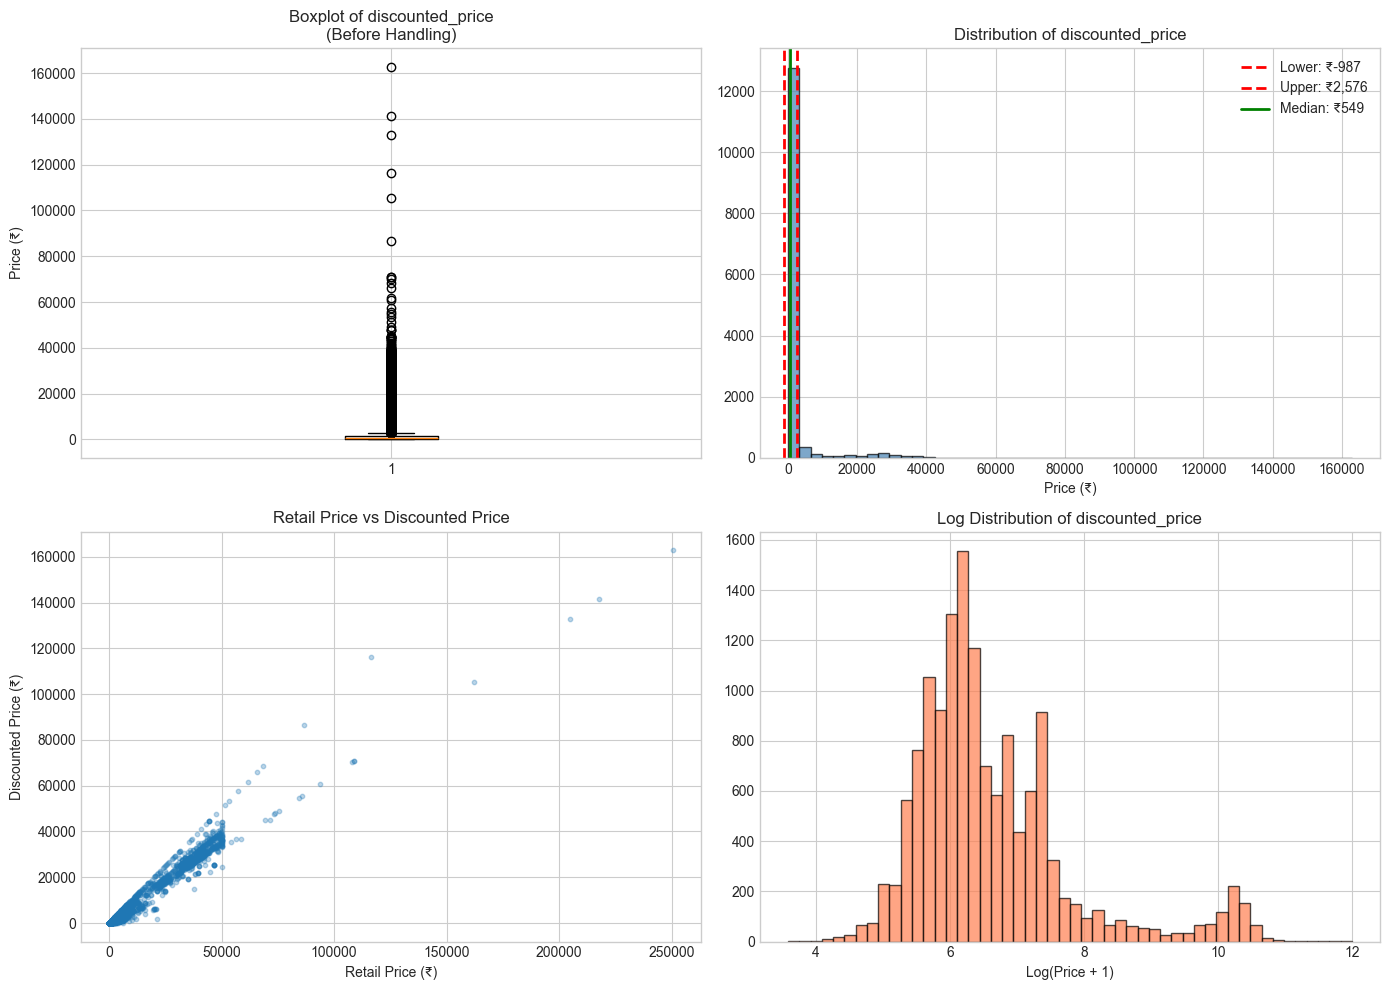

In [17]:
# ====================================
# VISUALIZE OUTLIERS
# ====================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Boxplot BEFORE handling
axes[0, 0].boxplot(df[TARGET].dropna())
axes[0, 0].set_title(f'Boxplot of {TARGET}\n(Before Handling)', fontsize=12)
axes[0, 0].set_ylabel('Price (₹)')

# 2. Histogram with bounds
axes[0, 1].hist(df[TARGET].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 1].axvline(lower, color='red', linestyle='--', linewidth=2, label=f'Lower: ₹{lower:,.0f}')
axes[0, 1].axvline(upper, color='red', linestyle='--', linewidth=2, label=f'Upper: ₹{upper:,.0f}')
axes[0, 1].axvline(df[TARGET].median(), color='green', linestyle='-', linewidth=2, label=f'Median: ₹{df[TARGET].median():,.0f}')
axes[0, 1].set_title(f'Distribution of {TARGET}', fontsize=12)
axes[0, 1].set_xlabel('Price (₹)')
axes[0, 1].legend()

# 3. Retail vs Discounted Price
axes[1, 0].scatter(df['retail_price'], df['discounted_price'], alpha=0.3, s=10)
axes[1, 0].set_xlabel('Retail Price (₹)')
axes[1, 0].set_ylabel('Discounted Price (₹)')
axes[1, 0].set_title('Retail Price vs Discounted Price', fontsize=12)

# 4. Price distribution by log scale
axes[1, 1].hist(np.log1p(df[TARGET].dropna()), bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1, 1].set_title(f'Log Distribution of {TARGET}', fontsize=12)
axes[1, 1].set_xlabel('Log(Price + 1)')

plt.tight_layout()

# Save figure
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/outlier_analysis.png', dpi=300, bbox_inches='tight')
print("✅ Figure saved: reports/figures/outlier_analysis.png")

plt.show()

In [18]:
# ====================================
# HANDLE OUTLIERS
# ====================================
print("=" * 60)
print("HANDLING OUTLIERS")
print("=" * 60)

print(f"📊 Shape BEFORE: {df.shape}")
print(f"📊 Price range BEFORE: ₹{df[TARGET].min():,.2f} - ₹{df[TARGET].max():,.2f}")

# METHOD: Cap outliers (Winsorization) - Recommended
# This keeps all data but limits extreme values

df[TARGET] = df[TARGET].clip(lower=max(0, lower), upper=upper)

# Also cap retail_price
if 'retail_price' in df.columns:
    retail_lower = df['retail_price'].quantile(0.25) - 1.5 * (df['retail_price'].quantile(0.75) - df['retail_price'].quantile(0.25))
    retail_upper = df['retail_price'].quantile(0.75) + 1.5 * (df['retail_price'].quantile(0.75) - df['retail_price'].quantile(0.25))
    df['retail_price'] = df['retail_price'].clip(lower=max(0, retail_lower), upper=retail_upper)

print(f"\n📊 Shape AFTER: {df.shape}")
print(f"📊 Price range AFTER: ₹{df[TARGET].min():,.2f} - ₹{df[TARGET].max():,.2f}")
print("\n✅ Outliers capped using Winsorization method!")

HANDLING OUTLIERS
📊 Shape BEFORE: (14058, 286)
📊 Price range BEFORE: ₹35.00 - ₹162,825.00

📊 Shape AFTER: (14058, 286)
📊 Price range AFTER: ₹35.00 - ₹2,575.88

✅ Outliers capped using Winsorization method!


In [19]:
# ====================================
# STEP 6: EXTRACT MAIN CATEGORY
# ====================================
print("=" * 60)
print("STEP 6: EXTRACT MAIN CATEGORY")
print("=" * 60)

# product_category_tree looks like: "Category1 >> SubCategory1 >> SubCategory2"

if 'product_category_tree' in df.columns:
    print("📊 Sample category tree:")
    print(df['product_category_tree'].head(3).tolist())
    
    # Extract main category (first level)
    def extract_main_category(category_tree):
        if pd.isna(category_tree):
            return 'Unknown'
        
        # Split by '>>' and take first part
        parts = str(category_tree).split('>>')
        main_cat = parts[0].strip()
        
        # Clean up
        main_cat = main_cat.replace('[', '').replace(']', '').replace('"', '')
        
        return main_cat if main_cat else 'Unknown'
    
    # Apply extraction
    df['main_category'] = df['product_category_tree'].apply(extract_main_category)
    
    print(f"\n📊 Unique main categories: {df['main_category'].nunique()}")
    print(f"\n📊 Top 10 categories:")
    print(df['main_category'].value_counts().head(10))

STEP 6: EXTRACT MAIN CATEGORY
📊 Sample category tree:
['["Clothing >> Women\'s Clothing >> Lingerie, Sleep & Swimwear >> Shorts >> Alisha Shorts >> Alisha Solid Women\'s Cycling Shorts"]', '["Furniture >> Living Room Furniture >> Sofa Beds & Futons >> FabHomeDecor Fabric Double Sofa Bed (Finish Colo..."]', '["Footwear >> Women\'s Footwear >> Ballerinas >> AW Bellies"]']

📊 Unique main categories: 261

📊 Top 10 categories:
main_category
Jewellery                     3521
Clothing                      3129
Mobiles & Accessories         1096
Automotive                    1010
Home Decor & Festive Needs     859
Home Furnishing                698
Computers                      572
Baby Care                      455
Tools & Hardware               387
Footwear                       375
Name: count, dtype: int64


In [20]:
# ====================================
# VIEW CATEGORICAL COLUMNS
# ====================================
print("=" * 60)
print("CATEGORICAL COLUMNS SUMMARY")
print("=" * 60)

categorical_cols = ['brand', 'main_category']

for col in categorical_cols:
    if col in df.columns:
        print(f"\n📊 {col}:")
        print(f"   Unique values: {df[col].nunique():,}")
        print(f"   Missing: {df[col].isnull().sum()}")
        print(f"   Top 5:")
        for cat, count in df[col].value_counts().head(5).items():
            print(f"      {cat}: {count:,}")

CATEGORICAL COLUMNS SUMMARY

📊 brand:
   Unique values: 3,481
   Missing: 0
   Top 5:
      Allure Auto: 468
      Regular: 308
      Voylla: 299
      Slim: 284
      TheLostPuppy: 229

📊 main_category:
   Unique values: 261
   Missing: 0
   Top 5:
      Jewellery: 3,521
      Clothing: 3,129
      Mobiles & Accessories: 1,096
      Automotive: 1,010
      Home Decor & Festive Needs: 859


In [21]:
# ====================================
# APPLY LABEL ENCODING
# ====================================
print("=" * 60)
print("STEP 7: LABEL ENCODING")
print("=" * 60)

# Store encoders for later use
label_encoders = {}

# Columns to encode
columns_to_encode = ['brand', 'main_category']

for col in columns_to_encode:
    if col in df.columns:
        # Create encoder
        le = LabelEncoder()
        
        # Create new encoded column
        new_col = f'{col}_encoded'
        df[new_col] = le.fit_transform(df[col].astype(str))
        
        # Store encoder
        label_encoders[col] = le
        
        print(f"\n✅ Encoded: {col} → {new_col}")
        print(f"   Unique classes: {len(le.classes_)}")
        print(f"   Sample mapping (first 5):")
        for i, cls in enumerate(le.classes_[:5]):
            print(f"      '{cls}' → {i}")
        if len(le.classes_) > 5:
            print(f"      ... and {len(le.classes_) - 5} more")

STEP 7: LABEL ENCODING

✅ Encoded: brand → brand_encoded
   Unique classes: 3481
   Sample mapping (first 5):
      '1OAK' → 0
      '3D Mat' → 1
      '3a AUTOCARE' → 2
      '3a Autocare' → 3
      '3kFactory' → 4
      ... and 3476 more

✅ Encoded: main_category → main_category_encoded
   Unique classes: 261
   Sample mapping (first 5):
      '883 Police Full Sleeve Solid Men's Jacket' → 0
      'ABEEZ Boys, Men, Girls (Black, Pack of 1)' → 1
      'ANAND ARCHIES Girls Flats' → 2
      'ANAND ARCHIES Girls Wedges' → 3
      'ANASAZI Casual 3/4 Sleeve Solid Women's Top' → 4
      ... and 256 more


In [22]:
# ====================================
# SAVE LABEL ENCODERS
# ====================================
os.makedirs('../models', exist_ok=True)

with open('../models/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

print("✅ Label encoders saved: models/label_encoders.pkl")
print(f"📊 Encoders saved for: {list(label_encoders.keys())}")

✅ Label encoders saved: models/label_encoders.pkl
📊 Encoders saved for: ['brand', 'main_category']


In [23]:
# ====================================
# BONUS: CREATE DISCOUNT FEATURES
# ====================================
print("=" * 60)
print("CREATING ADDITIONAL FEATURES")
print("=" * 60)

# Calculate discount amount
if 'retail_price' in df.columns and 'discounted_price' in df.columns:
    df['discount_amount'] = df['retail_price'] - df['discounted_price']
    print("✅ Created: discount_amount")
    
    # Calculate discount percentage
    df['discount_percentage'] = ((df['retail_price'] - df['discounted_price']) / df['retail_price']) * 100
    df['discount_percentage'] = df['discount_percentage'].clip(0, 100)  # Clip to valid range
    print("✅ Created: discount_percentage")
    
    print(f"\n📊 Discount Statistics:")
    print(f"   Average discount: ₹{df['discount_amount'].mean():,.2f}")
    print(f"   Average discount %: {df['discount_percentage'].mean():.1f}%")

CREATING ADDITIONAL FEATURES
✅ Created: discount_amount
✅ Created: discount_percentage

📊 Discount Statistics:
   Average discount: ₹785.90
   Average discount %: 44.3%


In [24]:
# ====================================
# FINAL DATA SUMMARY
# ====================================
print("=" * 60)
print("FINAL CLEANED DATA SUMMARY")
print("=" * 60)

print(f"\n📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

print(f"\n📊 Columns:")
for i, col in enumerate(df.columns, 1):
    dtype = df[col].dtype
    missing = df[col].isnull().sum()
    print(f"   {i:2}. {col:<25} | {str(dtype):<10} | Missing: {missing}")

print(f"\n📊 Missing Values: {df.isnull().sum().sum()}")
print(f"📊 Duplicates: {df.duplicated().sum()}")
print(f"📊 Memory Usage: {df.memory_usage(deep=True).sum() / (1024*1024):.2f} MB")

FINAL CLEANED DATA SUMMARY

📊 Shape: 14,058 rows × 291 columns

📊 Columns:
    1. uniq_id                   | object     | Missing: 0
    2. product_name              | object     | Missing: 0
    3. product_category_tree     | object     | Missing: 0
    4. pid                       | object     | Missing: 0
    5. retail_price              | float64    | Missing: 0
    6. discounted_price          | float64    | Missing: 0
    7. image                     | object     | Missing: 0
    8. description               | object     | Missing: 0
    9. brand                     | object     | Missing: 0
   10. product_specifications    | object     | Missing: 0
   11. price_2025-05-01          | float64    | Missing: 0
   12. price_2025-05-02          | float64    | Missing: 0
   13. price_2025-05-03          | float64    | Missing: 0
   14. price_2025-05-04          | float64    | Missing: 0
   15. price_2025-05-05          | float64    | Missing: 0
   16. price_2025-05-06          | float

In [25]:
# ====================================
# VIEW FINAL CLEANED DATA
# ====================================
print("=" * 60)
print("FINAL CLEANED DATA - SAMPLE")
print("=" * 60)
df.head(10)

FINAL CLEANED DATA - SAMPLE


,uniq_id,product_name,product_category_tree,pid,retail_price,discounted_price,image,description,brand,product_specifications,price_2025-05-01,price_2025-05-02,price_2025-05-03,price_2025-05-04,price_2025-05-05,price_2025-05-06,price_2025-05-07,price_2025-05-08,price_2025-05-09,price_2025-05-10,price_2025-05-11,price_2025-05-12,price_2025-05-13,price_2025-05-14,price_2025-05-15,price_2025-05-16,price_2025-05-17,price_2025-05-18,price_2025-05-19,price_2025-05-20,price_2025-05-21,price_2025-05-22,price_2025-05-23,price_2025-05-24,price_2025-05-25,price_2025-05-26,price_2025-05-27,price_2025-05-28,price_2025-05-29,price_2025-05-30,price_2025-05-31,price_2025-06-01,price_2025-06-02,price_2025-06-03,price_2025-06-04,price_2025-06-05,price_2025-06-06,price_2025-06-07,price_2025-06-08,price_2025-06-09,price_2025-06-10,price_2025-06-11,price_2025-06-12,price_2025-06-13,price_2025-06-14,price_2025-06-15,price_2025-06-16,price_2025-06-17,price_2025-06-18,price_2025-06-19,price_2025-06-20,price_2025-06-21,price_2025-06-22,price_2025-06-23,price_2025-06-24,price_2025-06-25,price_2025-06-26,price_2025-06-27,price_2025-06-28,price_2025-06-29,price_2025-06-30,price_2025-07-01,price_2025-07-02,price_2025-07-03,price_2025-07-04,price_2025-07-05,price_2025-07-06,price_2025-07-07,price_2025-07-08,price_2025-07-09,price_2025-07-10,price_2025-07-11,price_2025-07-12,price_2025-07-13,price_2025-07-14,price_2025-07-15,price_2025-07-16,price_2025-07-17,price_2025-07-18,price_2025-07-19,price_2025-07-20,price_2025-07-21,price_2025-07-22,price_2025-07-23,price_2025-07-24,price_2025-07-25,price_2025-07-26,price_2025-07-27,price_2025-07-28,price_2025-07-29,price_2025-07-30,price_2025-07-31,price_2025-08-01,price_2025-08-02,price_2025-08-03,price_2025-08-04,price_2025-08-05,price_2025-08-06,price_2025-08-07,price_2025-08-08,price_2025-08-09,price_2025-08-10,price_2025-08-11,price_2025-08-12,price_2025-08-13,price_2025-08-14,price_2025-08-15,price_2025-08-16,price_2025-08-17,price_2025-08-18,price_2025-08-19,price_2025-08-20,price_2025-08-21,price_2025-08-22,price_2025-08-23,price_2025-08-24,price_2025-08-25,price_2025-08-26,price_2025-08-27,price_2025-08-28,price_2025-08-29,price_2025-08-30,price_2025-08-31,price_2025-09-01,price_2025-09-02,price_2025-09-03,price_2025-09-04,price_2025-09-05,price_2025-09-06,price_2025-09-07,price_2025-09-08,price_2025-09-09,price_2025-09-10,price_2025-09-11,price_2025-09-12,price_2025-09-13,price_2025-09-14,price_2025-09-15,price_2025-09-16,price_2025-09-17,price_2025-09-18,price_2025-09-19,price_2025-09-20,price_2025-09-21,price_2025-09-22,price_2025-09-23,price_2025-09-24,price_2025-09-25,price_2025-09-26,price_2025-09-27,price_2025-09-28,price_2025-09-29,price_2025-09-30,price_2025-10-01,price_2025-10-02,price_2025-10-03,price_2025-10-04,price_2025-10-05,price_2025-10-06,price_2025-10-07,price_2025-10-08,price_2025-10-09,price_2025-10-10,price_2025-10-11,price_2025-10-12,price_2025-10-13,price_2025-10-14,price_2025-10-15,price_2025-10-16,price_2025-10-17,price_2025-10-18,price_2025-10-19,price_2025-10-20,price_2025-10-21,price_2025-10-22,price_2025-10-23,price_2025-10-24,price_2025-10-25,price_2025-10-26,price_2025-10-27,price_2025-10-28,price_2025-10-29,price_2025-10-30,price_2025-10-31,price_2025-11-01,price_2025-11-02,price_2025-11-03,price_2025-11-04,price_2025-11-05,price_2025-11-06,price_2025-11-07,price_2025-11-08,price_2025-11-09,price_2025-11-10,price_2025-11-11,price_2025-11-12,price_2025-11-13,price_2025-11-14,price_2025-11-15,price_2025-11-16,price_2025-11-17,price_2025-11-18,price_2025-11-19,price_2025-11-20,price_2025-11-21,price_2025-11-22,price_2025-11-23,price_2025-11-24,price_2025-11-25,price_2025-11-26,price_2025-11-27,price_2025-11-28,price_2025-11-29,price_2025-11-30,price_2025-12-01,price_2025-12-02,price_2025-12-03,price_2025-12-04,price_2025-12-05,price_2025-12-06,price_2025-12-07,price_2025-12-08,price_2025-12-09,price_2025-12-10,price_2025-12-11,price_2025-12-12,price_2025-12-13,price_2025-12-14

In [26]:
# ====================================
# SAVE CLEANED DATA
# ====================================
output_path = '../data/processed/02_cleaned_data.csv'

df.to_csv(output_path, index=False)

print("=" * 60)
print("✅ CLEANED DATA SAVED!")
print("=" * 60)
print(f"📁 Location: {output_path}")
print(f"📊 Rows: {df.shape[0]:,}")
print(f"📊 Columns: {df.shape[1]}")

✅ CLEANED DATA SAVED!
📁 Location: ../data/processed/02_cleaned_data.csv
📊 Rows: 14,058
📊 Columns: 291
